# Module 3: Pandas & Matplotlib with Mini-Project

This notebook introduces the Pandas library for data manipulation and Matplotlib for visualization. Two datasets are used: `../data/students.csv` (academic records) and `../data/sales.csv` (transaction records). Each section provides a runnable example followed by an exercise with its solution.

## 1. Pandas Basics

Pandas provides the `DataFrame` structure for tabular data and the `Series` for one-dimensional labeled arrays. The `read_csv()` function loads comma-separated files into a DataFrame.

### Creating DataFrames and Series from Scratch

While `read_csv()` is the most common way to load data, you can also build DataFrames and Series directly from Python data structures. This is useful for creating small test datasets or combining existing data.

In [1]:
import pandas as pd

# Create a Series with a custom index
scores = pd.Series([85, 92, 78], index=['Alice', 'Bob', 'Carol'])
print(scores)

# Create a DataFrame from a dictionary of lists
df_new = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Carol'],
    'gpa': [3.5, 3.2, 3.8],
    'department': ['CS', 'Physics', 'Math']
})
print(df_new)

# Create from a list of dictionaries (records)
records = [
    {'product': 'A', 'price': 10},
    {'product': 'B', 'price': 20},
    {'product': 'C', 'price': 15}
]
df_records = pd.DataFrame(records)
print(df_records)

Alice    85
Bob      92
Carol    78
dtype: int64
    name  gpa department
0  Alice  3.5         CS
1    Bob  3.2    Physics
2  Carol  3.8       Math
  product  price
0       A     10
1       B     20
2       C     15


In [2]:
import pandas as pd

df = pd.read_csv('../data/students.csv')


In [3]:
# EXERCISE: Load sales.csv into a DataFrame named 'sales' and display it.

# ---
# SOLUTION:
sales = pd.read_csv('../data/sales.csv')
sales

,transaction_id,date,product,category,quantity,unit_price,region,discount
0,T036,2024-10-28,Camping Tent 2P,Sports,10,980.62,South,0.00
1,T075,2024-08-11,Clean Code,Books,16,351.86,East,0.00
2,T084,2024-11-29,Resistance Bands Set,Sports,14,454.84,South,0.00
3,T020,2024-04-28,Deep Learning Intro,Books,7,69.83,West,0.00
4,T093,2024-07-27,Computer Networks,Books,8,692.46,West,0.00
...,...,...,...,...,...,...,...,...
95,T012,2024-06-10,Olive Oil 1L,Food,4,970.35,West,0.41
96,T091,2024-03-19,Deep Learning Intro,Books,17,965.67,East,0.46
97,T073,2024-12-17,Noise-Cancelling Headphones,Electronics,16,833.83,East,0.12
98,T071,2024-09-28,Pasta 500g,Food,18,334.80,West,0.00


## 2. Exploring Data

Use `head()` and `tail()` to inspect the first or last rows. `info()` reports column names, non-null counts, and data types; `describe()` computes summary statistics for numeric columns; `shape` and `columns` provide dimensional and naming metadata.

### Removing Duplicates

The `.drop_duplicates()` method removes duplicate rows. By default, it keeps the first occurrence. You can also specify a subset of columns to check for duplicates.

In [4]:
# Example: drop duplicates based on department
df_unique_depts = df.drop_duplicates(subset=['department'])
print('Unique departments:', len(df_unique_depts))

# Keep only the first occurrence of each department, showing name and department
df_unique_depts[['name', 'department']].head()

Unique departments: 5


,name,department
0,Omar,AI
2,Rania,Math
3,Yasmin,Data Science
4,Mariam,Physics
9,Hassan,CS


In [5]:
df.head(4)

,student_id,name,age,department,gpa,attendance_rate,credits_completed,scholarship
0,S001,Omar,22,AI,2.43,0.87,139,True
1,S002,Omar,19,AI,2.45,0.84,50,False
2,S003,Rania,21,Math,NaN,0.89,1,False
3,S004,Yasmin,23,Data Science,2.12,0.95,86,True


In [6]:
df.tail(3)

,student_id,name,age,department,gpa,attendance_rate,credits_completed,scholarship
47,S048,Lina,23,Data Science,3.3,0.91,57,True
48,S049,Aisha,22,CS,3.7,0.74,130,False
49,S050,Jessica,23,CS,2.0,0.96,45,False


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         50 non-null     str    
 1   name               50 non-null     str    
 2   age                50 non-null     int64  
 3   department         50 non-null     str    
 4   gpa                43 non-null     float64
 5   attendance_rate    46 non-null     float64
 6   credits_completed  50 non-null     int64  
 7   scholarship        50 non-null     bool   
dtypes: bool(1), float64(2), int64(2), str(3)
memory usage: 2.9 KB


In [8]:
df.describe()

,age,gpa,attendance_rate,credits_completed
count,50.000000,43.000000,46.000000,50.000000
mean,20.780000,2.748837,0.845217,69.660000
std,1.982474,0.570151,0.082858,43.255581
min,18.000000,1.760000,0.630000,1.000000
25%,19.000000,2.385000,0.802500,28.750000
50%,21.000000,2.670000,0.850000,70.000000
75%,22.000000,3.220000,0.907500,106.250000
max,25.000000,3.720000,0.980000,139.000000


In [9]:
print('Shape (rows, columns):', df.shape)
print('Column names:', df.columns.tolist())

Shape (rows, columns): (50, 8)
Column names: ['student_id', 'name', 'age', 'department', 'gpa', 'attendance_rate', 'credits_completed', 'scholarship']


In [10]:
# EXERCISE: Run .describe() on the sales DataFrame. What is the maximum unit_price?

# ---
# SOLUTION:
sales.describe()
# Maximum unit_price is 1200.00.

,quantity,unit_price,discount
count,100.000000,100.000000,100.000000
mean,10.800000,508.319400,0.135000
std,5.548683,293.816268,0.169976
min,1.000000,19.580000,0.000000
25%,6.000000,243.152500,0.000000
50%,10.500000,473.165000,0.000000
75%,16.000000,771.052500,0.292500
max,20.000000,980.880000,0.480000


## 3. Selecting Data

A single column selected with `df['col']` returns a Series; multiple columns (`df[['col1','col2']]`) return a DataFrame. Use `.loc[]` for label-based selection (inclusive of both endpoints) and `.iloc[]` for integer-position-based selection (standard Python slicing).

In [11]:
df['gpa'].head()

0    2.43
1    2.45
2     NaN
3    2.12
4    2.14
Name: gpa, dtype: float64

In [12]:
df[['name', 'department', 'gpa']].head()

,name,department,gpa
0,Omar,AI,2.43
1,Omar,AI,2.45
2,Rania,Math,NaN
3,Yasmin,Data Science,2.12
4,Mariam,Physics,2.14


In [13]:
df.loc[0:3, ['name', 'department']]

,name,department
0,Omar,AI
1,Omar,AI
2,Rania,Math
3,Yasmin,Data Science


In [14]:
df.iloc[5:8, 1:4]

,name,age,department
5,Emily,19,Physics
6,Ali,21,Data Science
7,Sara,20,Data Science


In [15]:
# EXERCISE: Use iloc to select rows 10 through 12 and columns 0 through 2 (student_id, name, age).

# ---
# SOLUTION:
df.iloc[10:13, 0:3]

,student_id,name,age
10,S011,Sarah,21
11,S012,Mona,22
12,S013,Jessica,25


## 4. Filtering

Boolean masks select rows satisfying a condition. Combine conditions with `&` (AND) or `|` (OR), each enclosed in parentheses. The `.isin()` method tests membership against a list of values.

In [16]:
df[df['gpa'] > 3.0]

,student_id,name,age,department,gpa,attendance_rate,credits_completed,scholarship
9,S010,Hassan,21,CS,3.27,NaN,16,False
12,S013,Jessica,25,CS,3.18,0.90,39,False
14,S015,Ahmed,19,Physics,3.05,0.88,87,True
15,S016,Lina,18,Data Science,3.72,0.87,129,False
17,S018,Amal,18,CS,3.56,0.91,78,False
18,S019,Khalid,19,Math,3.22,0.96,136,False
29,S030,Ahmed,24,Data Science,3.55,0.88,73,False
34,S035,Noor,22,AI,3.13,0.76,67,False
35,S036,Layla,25,Data Science,3.56,0.93,2,False
40,S041,Saif,25,Data Science,3.49,0.90,23,False


In [17]:
df[(df['department'] == 'CS') & (df['gpa'] > 2.5)]

,student_id,name,age,department,gpa,attendance_rate,credits_completed,scholarship
9,S010,Hassan,21,CS,3.27,NaN,16,False
12,S013,Jessica,25,CS,3.18,0.90,39,False
17,S018,Amal,18,CS,3.56,0.91,78,False
21,S022,Karim,21,CS,2.53,0.83,58,False
25,S026,James,19,CS,2.64,0.76,27,False
31,S032,Noor,18,CS,2.93,0.81,135,True
32,S033,Michael,20,CS,2.94,0.85,60,False
48,S049,Aisha,22,CS,3.70,0.74,130,False


In [18]:
df[df['department'].isin(['CS', 'Physics'])]

,student_id,name,age,department,gpa,attendance_rate,credits_completed,scholarship
4,S005,Mariam,23,Physics,2.14,0.63,117,False
5,S006,Emily,19,Physics,2.21,0.84,92,False
9,S010,Hassan,21,CS,3.27,NaN,16,False
11,S012,Mona,22,Physics,2.49,0.83,92,False
12,S013,Jessica,25,CS,3.18,0.90,39,False
14,S015,Ahmed,19,Physics,3.05,0.88,87,True
17,S018,Amal,18,CS,3.56,0.91,78,False
21,S022,Karim,21,CS,2.53,0.83,58,False
22,S023,Hassan,21,CS,NaN,0.90,18,False
23,S024,Amal,21,Physics,1.76,0.93,121,False


### OR Conditions and the `and`/`or` Trap

Use `|` (OR) to select rows that satisfy **either** condition. Like `&`, each condition must be wrapped in parentheses.

**Critical**: Python's built-in `and` and `or` do NOT work with pandas Series because they evaluate the entire object as a single boolean. Always use `&` (AND) and `|` (OR) for element-wise logical operations on DataFrames.

In [19]:
# OR condition: CS department OR GPA > 3.5
df[(df['department'] == 'CS') | (df['gpa'] > 3.5)][['name', 'department', 'gpa']].head()

# NOT condition with ~ (tilde)
df[~(df['department'] == 'CS')][['name', 'department']].head()

# between() is a convenient shorthand for range filtering
df[df['gpa'].between(2.5, 3.5)][['name', 'gpa']].head()

,name,gpa
7,Sara,2.56
9,Hassan,3.27
10,Sarah,2.51
12,Jessica,3.18
14,Ahmed,3.05


In [20]:
# EXERCISE: Filter for students aged 22 or older with GPA above 2.5.

# ---
# SOLUTION:
df[(df['age'] >= 22) & (df['gpa'] > 2.5)]

,student_id,name,age,department,gpa,attendance_rate,credits_completed,scholarship
12,S013,Jessica,25,CS,3.18,0.90,39,False
29,S030,Ahmed,24,Data Science,3.55,0.88,73,False
34,S035,Noor,22,AI,3.13,0.76,67,False
35,S036,Layla,25,Data Science,3.56,0.93,2,False
37,S038,Sarah,22,AI,2.82,0.82,77,False
40,S041,Saif,25,Data Science,3.49,0.90,23,False
46,S047,Karim,22,AI,3.30,0.67,9,False
47,S048,Lina,23,Data Science,3.30,0.91,57,True
48,S049,Aisha,22,CS,3.70,0.74,130,False


## 5. Handling Missing Data

`isnull()` returns a boolean mask for missing entries; `.sum()` counts NaN per column. `dropna()` removes rows or columns containing NaN, while `fillna()` replaces NaN with a specified value such as the column mean or a constant.

In [21]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
student_id           0
name                 0
age                  0
department           0
gpa                  7
attendance_rate      4
credits_completed    0
scholarship          0
dtype: int64


In [22]:
df_clean = df.dropna()
print(f'Rows before dropna: {df.shape[0]}, after: {df_clean.shape[0]}')

Rows before dropna: 50, after: 39


In [23]:
df['gpa'] = df['gpa'].fillna(df['gpa'].mean())
df['attendance_rate'] = df['attendance_rate'].fillna(df['attendance_rate'].median())
print('After filling:')
print(df.isnull().sum())

After filling:
student_id           0
name                 0
age                  0
department           0
gpa                  0
attendance_rate      0
credits_completed    0
scholarship          0
dtype: int64


In [24]:
# EXERCISE: On the sales DataFrame, fill missing 'quantity' with 0 and missing 'region' with 'Unknown'.

# ---
# SOLUTION:
sales['quantity'] = sales['quantity'].fillna(0)
sales['region'] = sales['region'].fillna('Unknown')
print(sales.isnull().sum())

transaction_id    0
date              0
product           0
category          0
quantity          0
unit_price        0
region            0
discount          0
dtype: int64


## 6. Sorting and Grouping

`sort_values()` orders rows by one or more columns. `groupby()` splits data by a categorical column, applies an aggregation function (`mean`, `sum`, `count`), and combines the results. Use `.agg()` to compute multiple aggregations simultaneously.

### More Missing-Data Options

`dropna()` has several useful variants:
- `axis=1` drops **columns** with NaN instead of rows.
- `how='all'` only drops a row/column if **every** value is NaN.
- `thresh=n` keeps rows with at least `n` non-null values.

`fillna()` can also forward-fill (`ffill`) or backward-fill (`bfill`) values, which is useful for time-series data.

In [25]:
# dropna variants
print('Drop columns with any NaN:', df.dropna(axis=1).shape)
print('Drop rows where ALL values are NaN:', df.dropna(how='all').shape)
print('Keep rows with at least 5 non-null values:', df.dropna(thresh=5).shape)

# fillna with forward fill and backward fill
s = pd.Series([1.0, None, None, 4.0, None])
print('Original:', s.tolist())
print('ffill:  ', s.ffill().tolist())
print('bfill:  ', s.bfill().tolist())

Drop columns with any NaN: (50, 8)
Drop rows where ALL values are NaN: (50, 8)
Keep rows with at least 5 non-null values: (50, 8)
Original: [1.0, nan, nan, 4.0, nan]
ffill:   [1.0, 1.0, 1.0, 4.0, 4.0]
bfill:   [1.0, 4.0, 4.0, 4.0, nan]


### Counting Rows per Group with `.size()`

While `.agg()` computes summary statistics, `.size()` counts the number of rows in each group. This is useful for finding class sizes, transaction counts, or frequency distributions.

In [26]:
def classify_gpa(value):
    if value >= 3.0:
        return 'High'
    elif value >= 2.5:
        return 'Medium'
    else:
        return 'Low'

df['gpa_category'] = df['gpa'].apply(classify_gpa)
df[['name', 'gpa', 'gpa_category']].head()

,name,gpa,gpa_category
0,Omar,2.430000,Low
1,Omar,2.450000,Low
2,Rania,2.748837,Medium
3,Yasmin,2.120000,Low
4,Mariam,2.140000,Low


In [27]:
# Count students per department
dept_counts = df.groupby('department').size().reset_index(name='student_count')
print(dept_counts)

# Multi-key grouping with size
df.groupby(['department', 'gpa_category']).size().reset_index(name='count').head()

     department  student_count
0            AI              8
1            CS             13
2  Data Science             12
3          Math              9
4       Physics              8


,department,gpa_category,count
0,AI,High,3
1,AI,Low,3
2,AI,Medium,2
3,CS,High,4
4,CS,Low,3


In [28]:
df.sort_values('gpa', ascending=False)[['name', 'department', 'gpa']].head(5)

,name,department,gpa
15,Lina,Data Science,3.72
48,Aisha,CS,3.70
35,Layla,Data Science,3.56
17,Amal,CS,3.56
29,Ahmed,Data Science,3.55


In [29]:
df.groupby('department').agg(
    student_count=('student_id', 'count'),
    avg_gpa=('gpa', 'mean'),
    max_gpa=('gpa', 'max'),
    avg_credits=('credits_completed', 'mean')
).round(2)

,student_count,avg_gpa,max_gpa,avg_credits
department,,,,
AI,8,2.84,3.48,72.00
CS,13,2.77,3.70,58.08
Data Science,12,3.06,3.72,60.42
Math,9,2.53,3.22,76.44
Physics,8,2.40,3.05,92.38


In [30]:
# EXERCISE: Group the sales DataFrame by 'category'. Compute total quantity and average unit_price per category.

# ---
# SOLUTION:
sales.groupby('category').agg(
    total_quantity=('quantity', 'sum'),
    avg_unit_price=('unit_price', 'mean')
).round(2)

,total_quantity,avg_unit_price
category,,
Books,236,525.38
Clothing,175,537.16
Electronics,230,467.41
Food,222,434.19
Sports,217,582.69


## 7. Adding Columns

New columns can be created via vectorized arithmetic operations on existing columns. The `apply()` method passes each element of a Series through a custom function, suitable for categorical mappings or complex transformations.

In [31]:
df['credits_remaining'] = 140 - df['credits_completed']
df[['name', 'credits_completed', 'credits_remaining']].head()

,name,credits_completed,credits_remaining
0,Omar,139,1
1,Omar,50,90
2,Rania,1,139
3,Yasmin,86,54
4,Mariam,117,23


### Mapping Values with `.map()`

The `.map()` method replaces each value in a Series according to a dictionary or function. It is ideal for converting categorical codes to labels, or applying a lookup table.

In [32]:
# Map department codes to full names
dept_names = {'CS': 'Computer Science', 'Physics': 'Physics', 'Math': 'Mathematics'}
df['dept_full'] = df['department'].map(dept_names)
df[['name', 'department', 'dept_full']].head()

# Map with a function (e.g., scale GPA to percentage)
df['gpa_pct'] = df['gpa'].map(lambda g: round(g / 4.0 * 100, 1))
df[['name', 'gpa', 'gpa_pct']].head()

,name,gpa,gpa_pct
0,Omar,2.430000,60.8
1,Omar,2.450000,61.3
2,Rania,2.748837,68.7
3,Yasmin,2.120000,53.0
4,Mariam,2.140000,53.5


In [33]:
# EXERCISE: Add a 'revenue' column to the sales DataFrame: revenue = quantity * unit_price * (1 - discount).

# ---
# SOLUTION:
sales['revenue'] = sales['quantity'] * sales['unit_price'] * (1 - sales['discount'])
sales[['product', 'quantity', 'unit_price', 'discount', 'revenue']].head()

,product,quantity,unit_price,discount,revenue
0,Camping Tent 2P,10,980.62,0.0,9806.20
1,Clean Code,16,351.86,0.0,5629.76
2,Resistance Bands Set,14,454.84,0.0,6367.76
3,Deep Learning Intro,7,69.83,0.0,488.81
4,Computer Networks,8,692.46,0.0,5539.68


## 8. Matplotlib Basics

Matplotlib is imported via `import matplotlib.pyplot as plt`. A style sheet controls figure aesthetics; `plt.show()` renders the current figure. In Jupyter, plots display inline by default.

In [34]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

plt.figure()
plt.show()

<Figure size 640x480 with 0 Axes>

In [35]:
# EXERCISE: Switch to the 'seaborn-v0_8-darkgrid' style, create an empty figure, then restore 'ggplot'.

# ---
# SOLUTION:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure()
plt.show()
plt.style.use('ggplot')

<Figure size 640x480 with 0 Axes>

## 9. Line Plot

`plt.plot()` draws a line through ordered data points. Axes labels, a title, and a legend improve readability. Rotating tick labels with `plt.xticks(rotation=)` prevents overlap on dense x-axes.

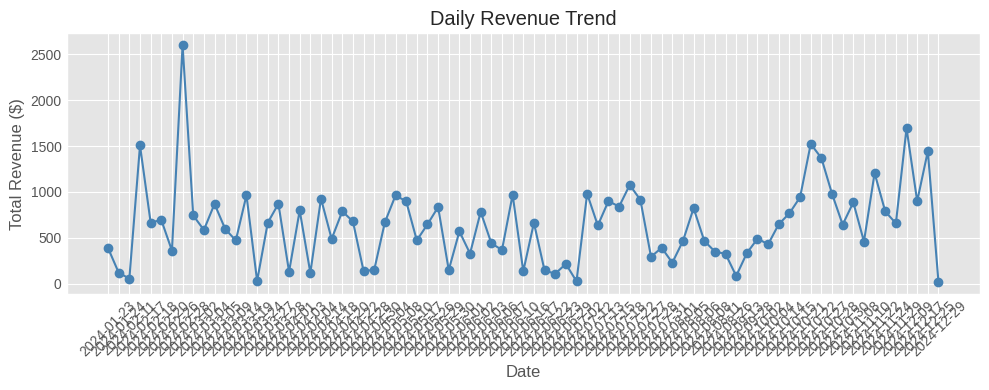

In [36]:
daily = sales.groupby('date')['unit_price'].sum().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(daily['date'], daily['unit_price'], marker='o', linestyle='-', color='steelblue')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

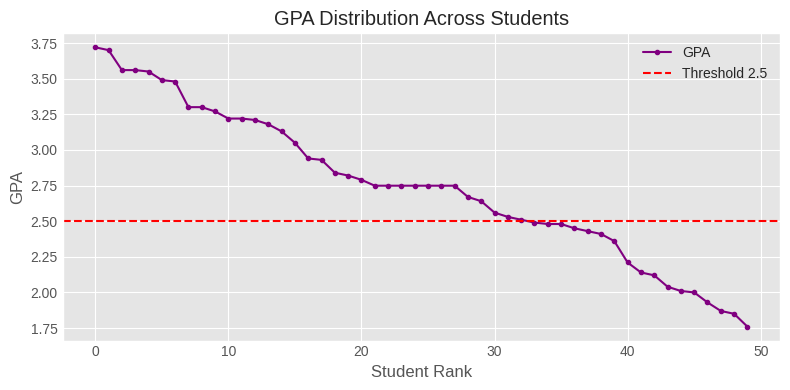

In [37]:
# EXERCISE: Plot GPA values sorted in descending order as a line, and add a dashed red horizontal line at y=2.5 as a threshold.

# ---
# SOLUTION:
gpa_sorted = df['gpa'].sort_values(ascending=False).reset_index(drop=True)
plt.figure(figsize=(8, 4))
plt.plot(gpa_sorted, marker='.', linestyle='-', color='purple', label='GPA')
plt.axhline(y=2.5, color='red', linestyle='--', label='Threshold 2.5')
plt.xlabel('Student Rank')
plt.ylabel('GPA')
plt.title('GPA Distribution Across Students')
plt.legend()
plt.tight_layout()
plt.show()

### Object-Oriented Matplotlib Style (Recommended)

The **object-oriented (OO) style** is the preferred approach for production code. You explicitly create a `Figure` and one or more `Axes` objects, then call methods on them. This avoids hidden global state and makes your code clearer and more reusable.

Pattern: `fig, ax = plt.subplots()` creates a figure with a single Axes.

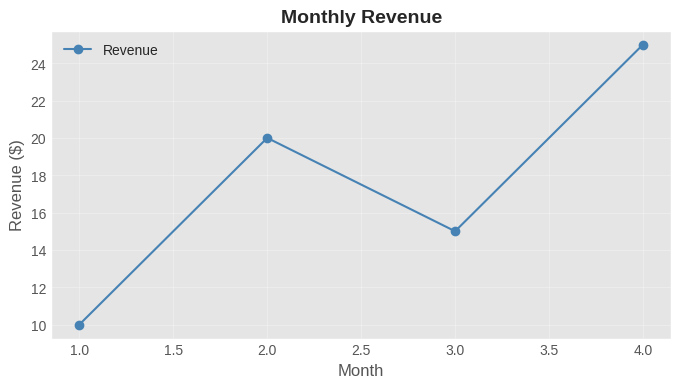

In [38]:
import matplotlib.pyplot as plt

# OO style: explicit figure and axes
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([1, 2, 3, 4], [10, 20, 15, 25], marker='o', color='steelblue', label='Revenue')
ax.set_title('Monthly Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 10. Bar Plot

Bar charts compare categorical values. `plt.bar()` positions bars at specified x-coordinates; grouped bars require offset computation. DataFrame `.plot(kind='bar')` provides a convenient shorthand.

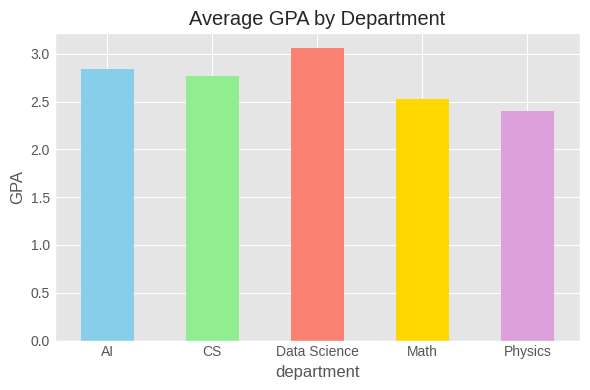

In [39]:
avg_by_dept = df.groupby('department')['gpa'].mean()

plt.figure(figsize=(6, 4))
avg_by_dept.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon', 'gold', 'plum'])
plt.title('Average GPA by Department')
plt.ylabel('GPA')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

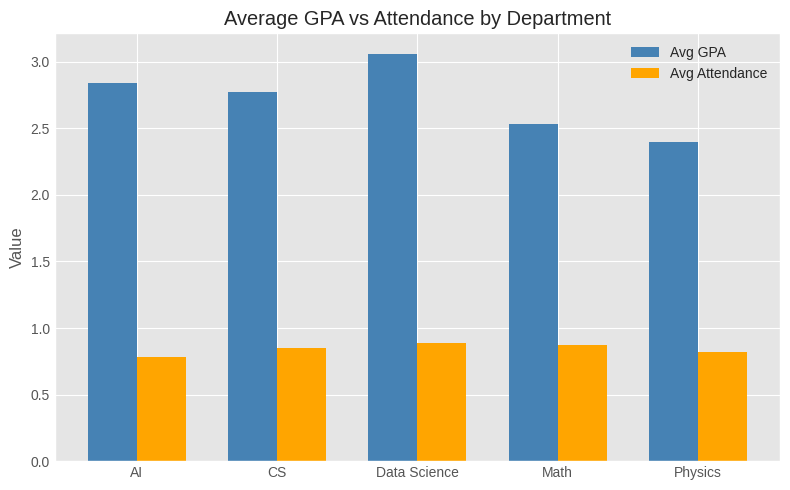

In [40]:
grouped = df.groupby('department').agg(
    avg_gpa=('gpa', 'mean'),
    avg_attendance=('attendance_rate', 'mean')
)

x = range(len(grouped))
w = 0.35
plt.figure(figsize=(8, 5))
plt.bar([i - w/2 for i in x], grouped['avg_gpa'], w, label='Avg GPA', color='steelblue')
plt.bar([i + w/2 for i in x], grouped['avg_attendance'], w, label='Avg Attendance', color='orange')
plt.xticks(x, grouped.index)
plt.ylabel('Value')
plt.title('Average GPA vs Attendance by Department')
plt.legend()
plt.tight_layout()
plt.show()

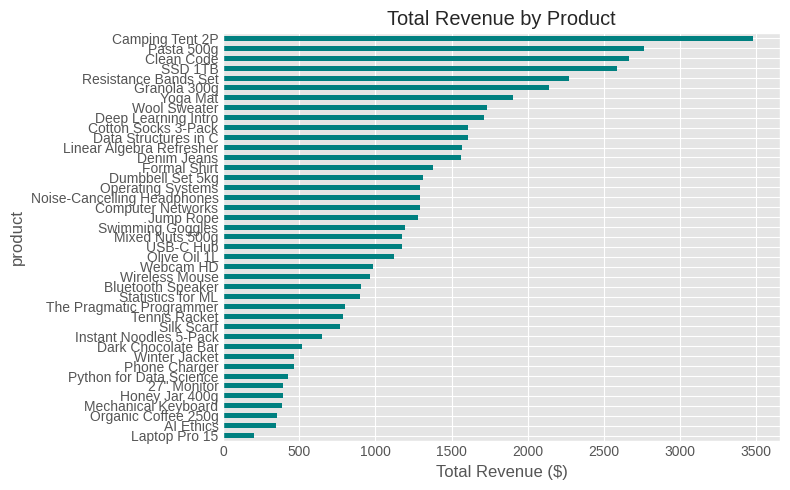

In [41]:
# EXERCISE: Create a horizontal bar chart of total unit_price summed by product from the sales DataFrame.

# ---
# SOLUTION:
product_revenue = sales.groupby('product')['unit_price'].sum().sort_values()
plt.figure(figsize=(8, 5))
product_revenue.plot(kind='barh', color='teal')
plt.title('Total Revenue by Product')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

## 11. Histogram

`plt.hist()` bins a numeric column and plots frequency counts. The `bins` parameter controls granularity; `edgecolor` adds separation between bars. Histograms reveal the shape, spread, and modality of a distribution.

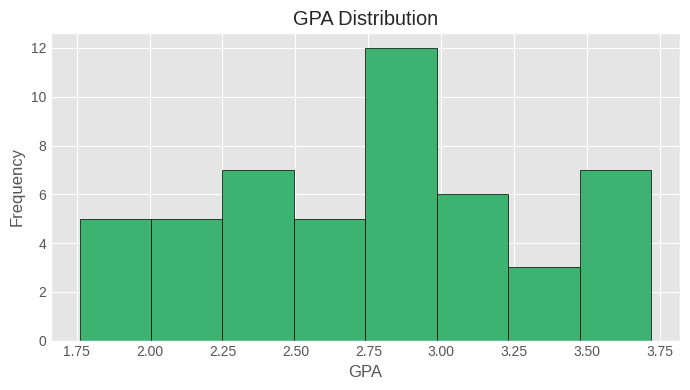

In [42]:
plt.figure(figsize=(7, 4))
plt.hist(df['gpa'], bins=8, edgecolor='black', color='mediumseagreen')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.title('GPA Distribution')
plt.tight_layout()
plt.show()

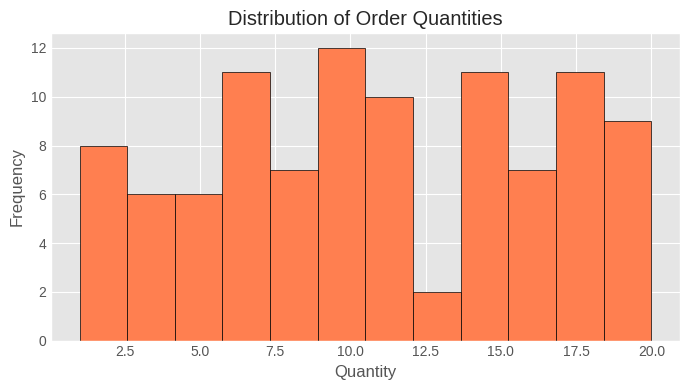

In [43]:
# EXERCISE: Plot a histogram of the 'quantity' column from the sales DataFrame with 12 bins.

# ---
# SOLUTION:
plt.figure(figsize=(7, 4))
plt.hist(sales['quantity'].dropna(), bins=12, edgecolor='black', color='coral')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.title('Distribution of Order Quantities')
plt.tight_layout()
plt.show()

## 12. Scatter Plot

`plt.scatter()` maps two numeric variables to x and y coordinates. The `c` parameter maps a third variable to color using a colormap; `alpha` controls transparency for overlapping points. A colorbar legend decodes the mapping.

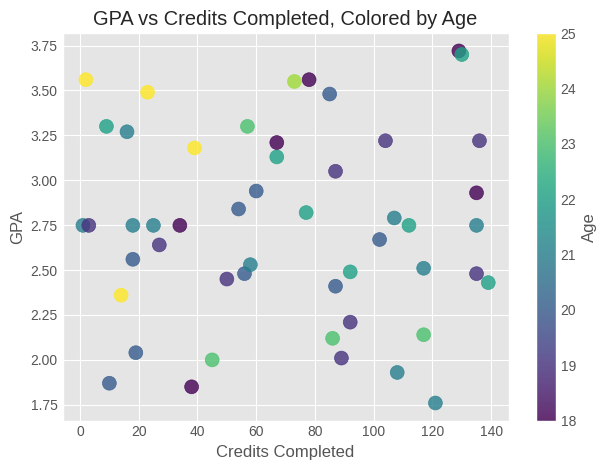

In [44]:
scatter = plt.scatter(df['credits_completed'], df['gpa'],
                      c=df['age'], cmap='viridis', s=100, alpha=0.8)
plt.colorbar(scatter, label='Age')
plt.xlabel('Credits Completed')
plt.ylabel('GPA')
plt.title('GPA vs Credits Completed, Colored by Age')
plt.tight_layout()
plt.show()

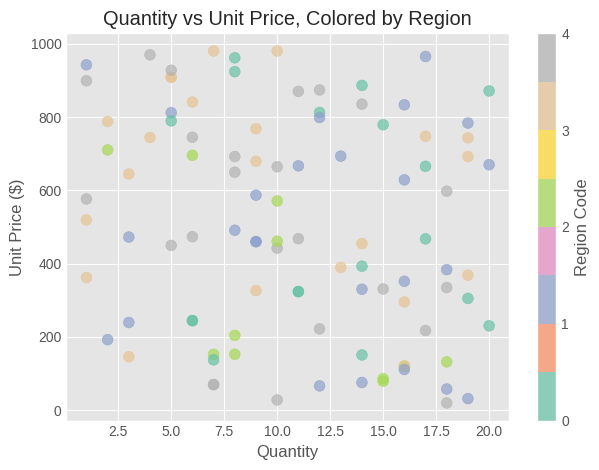

In [45]:
# EXERCISE: Scatter plot of quantity vs unit_price from the sales DataFrame, colored by region (use category codes for numeric mapping).

# ---
# SOLUTION:
region_codes = sales['region'].astype('category').cat.codes
sc = plt.scatter(sales['quantity'], sales['unit_price'],
                 c=region_codes, cmap='Set2', alpha=0.7, s=60)
plt.colorbar(sc, ticks=range(sales['region'].nunique()), label='Region Code')
plt.xlabel('Quantity')
plt.ylabel('Unit Price ($)')
plt.title('Quantity vs Unit Price, Colored by Region')
plt.tight_layout()
plt.show()

## 13. Subplots

`plt.subplots(nrows, ncols)` creates a figure with a grid of Axes objects. Each subplot is accessed by row-column indexing (e.g., `axes[0, 0]`) and configured independently. Subplots are useful for juxtaposing related views of the same dataset.

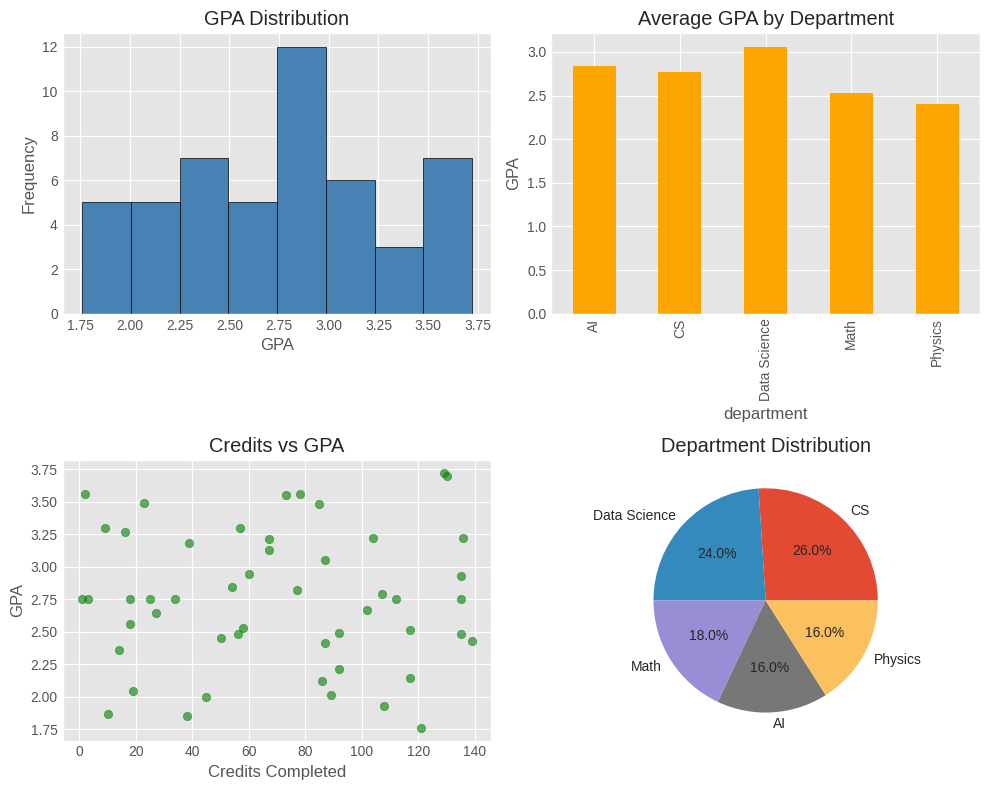

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(df['gpa'], bins=8, color='steelblue', edgecolor='black')
axes[0, 0].set_title('GPA Distribution')
axes[0, 0].set_xlabel('GPA')
axes[0, 0].set_ylabel('Frequency')

df.groupby('department')['gpa'].mean().plot(kind='bar', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Average GPA by Department')
axes[0, 1].set_ylabel('GPA')

axes[1, 0].scatter(df['credits_completed'], df['gpa'], alpha=0.6, color='green')
axes[1, 0].set_xlabel('Credits Completed')
axes[1, 0].set_ylabel('GPA')
axes[1, 0].set_title('Credits vs GPA')

dept_counts = df['department'].value_counts()
axes[1, 1].pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%')
axes[1, 1].set_title('Department Distribution')

plt.tight_layout()
plt.show()

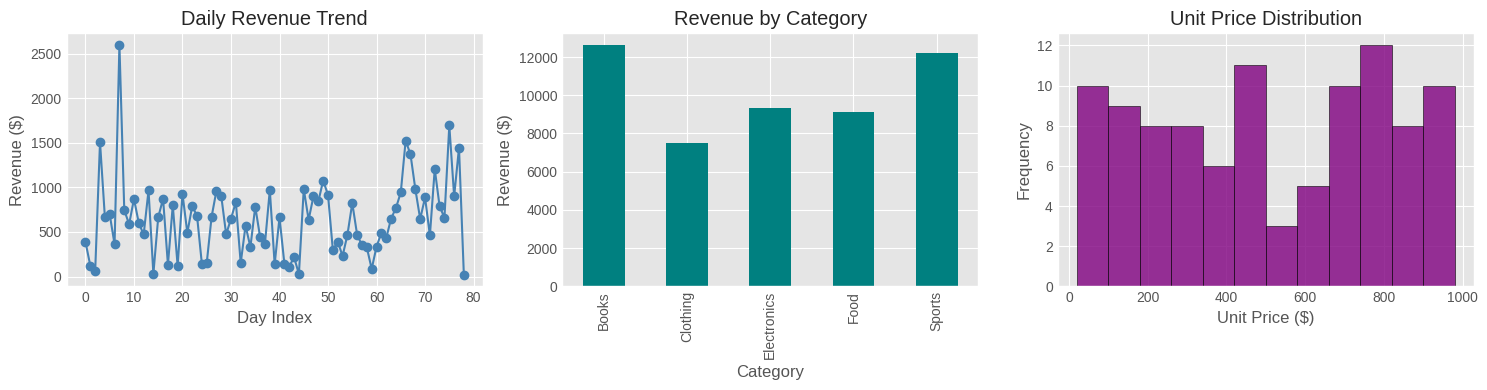

In [47]:
# EXERCISE: Create a 1-row by 3-column subplot with a line chart of daily unit_price sums, a bar chart of revenue by category, and a histogram of unit_price from the sales DataFrame.

# ---
# SOLUTION:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

daily = sales.groupby('date')['unit_price'].sum()
axes[0].plot(range(len(daily)), daily.values, marker='o', color='steelblue')
axes[0].set_title('Daily Revenue Trend')
axes[0].set_xlabel('Day Index')
axes[0].set_ylabel('Revenue ($)')

sales.groupby('category')['unit_price'].sum().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Revenue by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Revenue ($)')

axes[2].hist(sales['unit_price'].dropna(), bins=12, edgecolor='black', color='purple', alpha=0.8)
axes[2].set_title('Unit Price Distribution')
axes[2].set_xlabel('Unit Price ($)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 14. Mini-Project: End-to-End Sales Analysis

The following section integrates all techniques covered above into a single analytical workflow. Each step loads, cleans, explores, visualizes, and interprets the sales dataset.

### Saving Figures

Use `fig.savefig('filename.png')` to save a figure to disk. Important parameters:
- `dpi` controls resolution (default 100; use 300 for publication quality).
- `bbox_inches='tight'` removes extra white space around the figure.

**Critical rule**: Always call `savefig()` **before** `plt.show()`. `show()` clears the current figure, so saving after it produces an empty file.

## Common Gotchas and Best Practices

A few pitfalls catch almost every beginner. Keep these in mind as you work through the mini-project.

In [48]:
import pandas as pd
import numpy as np

# 1. SettingWithCopyWarning: chained indexing can return a copy or a view unpredictably
# BAD:  df[df['gpa'] > 3.0]['name'] = 'Honors'   # may not modify df; triggers warning
# GOOD: df.loc[df['gpa'] > 3.0, 'name'] = 'Honors'  # guaranteed to modify df

# 2. GroupBy results need reset_index() to become a normal DataFrame
# grouped = df.groupby('department')['gpa'].mean()  # this is a Series with MultiIndex
# grouped_df = df.groupby('department')['gpa'].mean().reset_index()  # clean DataFrame

# 3. show() clears the figure — save before you show
# fig.savefig('plot.png')  # do this FIRST
# plt.show()               # then display

# 4. NaN != NaN — always use pd.isna() or .isnull() to test for missing values
print(np.nan == np.nan)   # False!
print(pd.isna(np.nan))    # True — correct way

# 5. inplace=True modifies the DataFrame in place and returns None
# Prefer explicit assignment: df = df.dropna() instead of df.dropna(inplace=True)

False
True


Saved to sample_plot.png


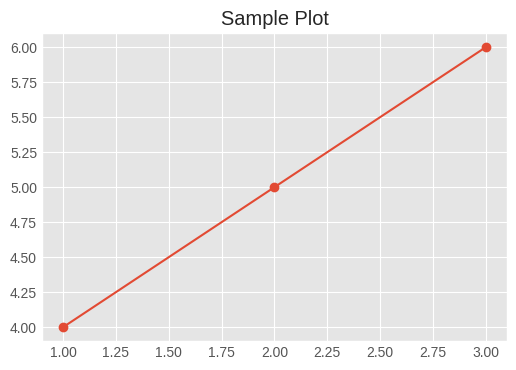

In [49]:
# Create and save a figure
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([1, 2, 3], [4, 5, 6], marker='o')
ax.set_title('Sample Plot')

# SAVE FIRST, then show
fig.savefig('sample_plot.png', dpi=150, bbox_inches='tight')
print('Saved to sample_plot.png')

plt.show()  # display after saving

### Step 1: Load and Inspect

Reload the sales dataset from disk to ensure a clean starting state independent of earlier modifications. Display the shape and first five rows.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

sales = pd.read_csv('../data/sales.csv')
print('Shape:', sales.shape)
print('Columns:', sales.columns.tolist())
sales.head()

Shape: (100, 8)
Columns: ['transaction_id', 'date', 'product', 'category', 'quantity', 'unit_price', 'region', 'discount']


,transaction_id,date,product,category,quantity,unit_price,region,discount
0,T036,2024-10-28,Camping Tent 2P,Sports,10,980.62,South,0.0
1,T075,2024-08-11,Clean Code,Books,16,351.86,East,0.0
2,T084,2024-11-29,Resistance Bands Set,Sports,14,454.84,South,0.0
3,T020,2024-04-28,Deep Learning Intro,Books,7,69.83,West,0.0
4,T093,2024-07-27,Computer Networks,Books,8,692.46,West,0.0


### Step 2: Clean

Identify missing values per column. Fill missing `quantity` with the column median (robust to outliers) and missing `region` with the constant `'Unknown'`. Drop any rows that still have NaN in `unit_price`, as price is critical for revenue calculations.

In [51]:
print('Missing values before cleaning:')
print(sales.isnull().sum())

sales['quantity'] = sales['quantity'].fillna(sales['quantity'].median())
sales['region'] = sales['region'].fillna('Unknown')
sales = sales.dropna(subset=['unit_price'])

print('\nMissing values after cleaning:')
print(sales.isnull().sum())

Missing values before cleaning:
transaction_id    0
date              0
product           0
category          0
quantity          0
unit_price        0
region            0
discount          0
dtype: int64

Missing values after cleaning:
transaction_id    0
date              0
product           0
category          0
quantity          0
unit_price        0
region            0
discount          0
dtype: int64


### Step 3: Explore

Compute summary statistics and aggregate metrics by category: total revenue, average quantity, and transaction count. Identify the top three regions by total revenue.

In [52]:
sales.describe().round(2)

,quantity,unit_price,discount
count,100.00,100.00,100.00
mean,10.80,508.32,0.14
std,5.55,293.82,0.17
min,1.00,19.58,0.00
25%,6.00,243.15,0.00
50%,10.50,473.16,0.00
75%,16.00,771.05,0.29
max,20.00,980.88,0.48


In [53]:
sales.groupby('category').agg(
    total_unit_price=('unit_price', 'sum'),
    avg_quantity=('quantity', 'mean'),
    transaction_count=('product', 'count')
).round(2)

,total_unit_price,avg_quantity,transaction_count
category,,,
Books,12609.13,9.83,24
Clothing,7520.23,12.50,14
Electronics,9348.23,11.50,20
Food,9117.93,10.57,21
Sports,12236.42,10.33,21


In [54]:
sales.groupby('region')['unit_price'].sum().sort_values(ascending=False).head(3)

region
South    13414.27
West     12431.33
East     12108.35
Name: unit_price, dtype: float64

### Step 4: Visualize

Produce four complementary visualizations: a horizontal bar chart of revenue by category, a line chart of daily revenue, a stacked bar chart of revenue by region and category, and a histogram of unit prices.

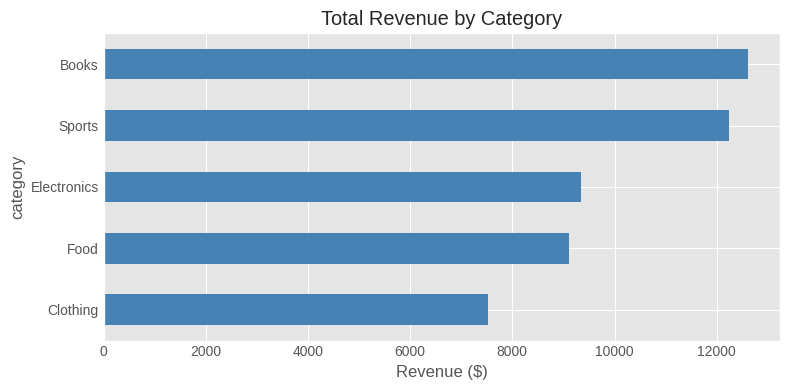

In [55]:
cat_rev = sales.groupby('category')['unit_price'].sum().sort_values()
plt.figure(figsize=(8, 4))
cat_rev.plot(kind='barh', color='steelblue')
plt.title('Total Revenue by Category')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

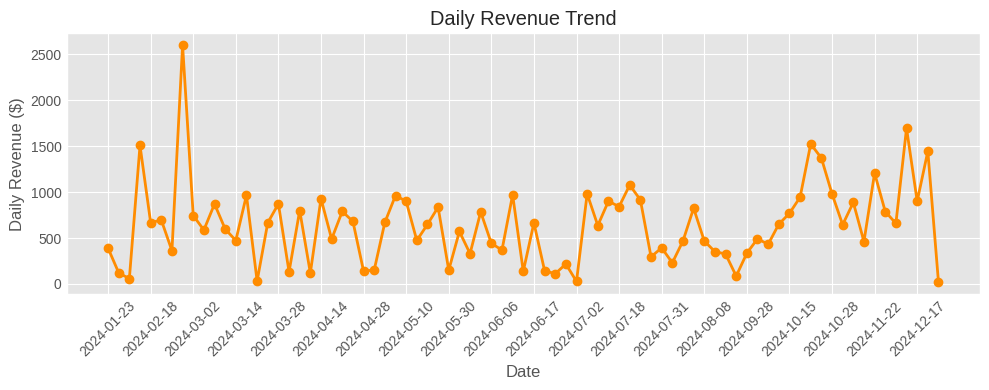

In [56]:
daily_rev = sales.groupby('date')['unit_price'].sum()
plt.figure(figsize=(10, 4))
plt.plot(range(len(daily_rev)), daily_rev.values, marker='o', color='darkorange', linewidth=2)
tick_positions = range(0, len(daily_rev), 4)
plt.xticks(tick_positions, [daily_rev.index[i] for i in tick_positions], rotation=45)
plt.xlabel('Date')
plt.ylabel('Daily Revenue ($)')
plt.title('Daily Revenue Trend')
plt.tight_layout()
plt.show()

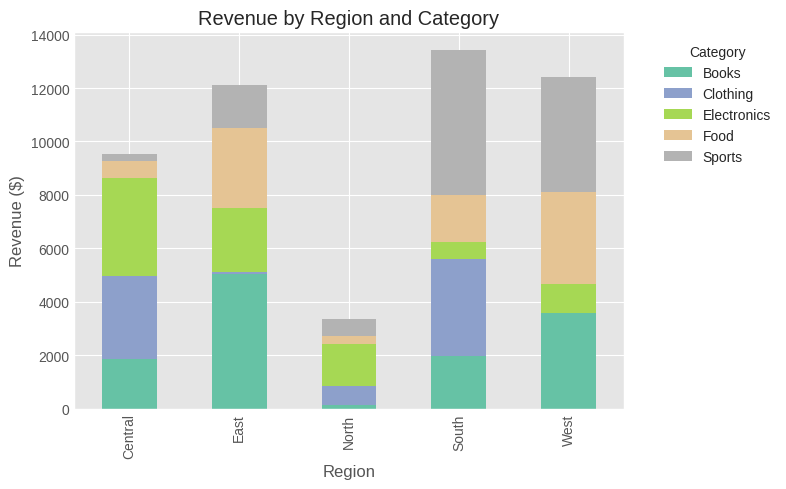

In [57]:
cross_tab = sales.pivot_table(
    values='unit_price', index='region',
    columns='category', aggfunc='sum', fill_value=0
)
cross_tab.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')
plt.title('Revenue by Region and Category')
plt.xlabel('Region')
plt.ylabel('Revenue ($)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

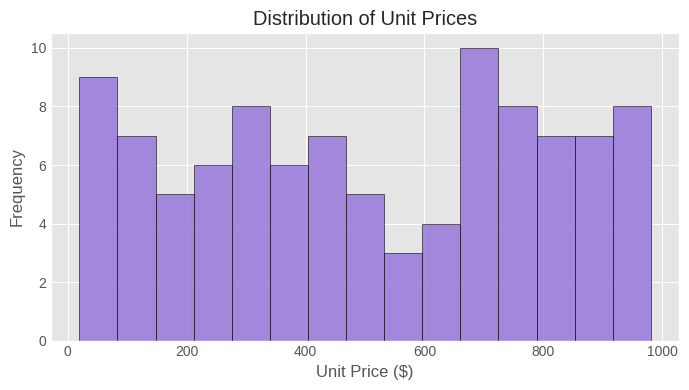

In [58]:
plt.figure(figsize=(7, 4))
plt.hist(sales['unit_price'], bins=15, edgecolor='black', color='mediumpurple', alpha=0.8)
plt.xlabel('Unit Price ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Unit Prices')
plt.tight_layout()
plt.show()

### Step 5: Summarize Findings

The analysis yields the following observations:

1. The highest-priced items (such as Laptop Pro at $1,200/unit) generate disproportionate total revenue despite lower sales volume.
2. The North and East regions consistently produce the strongest revenue performance across multiple product categories.
3. The unit price distribution exhibits multimodality, with distinct clusters of low-cost and premium items.
4. Missing data volumes are modest; most gaps occur in `quantity` and `region` and can be addressed through median imputation and a constant fill without discarding rows.
5. Category-level aggregation reveals that Electronics and Books are the primary revenue drivers, while Clothing and Sports contribute smaller but consistent shares.

## 15. Working with Dates

The `pd.to_datetime()` function converts string columns to datetime objects. Once converted, the `.dt` accessor exposes date-time properties such as `.dt.month`, `.dt.year`, `.dt.day`, and `.dt.day_name()`. These properties enable time-based grouping and filtering.

In [59]:
# Convert the 'date' column and extract month/year
sales['date'] = pd.to_datetime(sales['date'])
sales['month'] = sales['date'].dt.month
sales['year'] = sales['date'].dt.year

print('Data types after conversion:')
print(sales[['date', 'month', 'year']].dtypes)
print()

# Group by month and sum unit_price
monthly_revenue = sales.groupby('month')['unit_price'].sum()
print('Total unit_price by month:')
print(monthly_revenue)

Data types after conversion:
date     datetime64[us]
month             int32
year              int32
dtype: object

Total unit_price by month:
month
1      511.16
2     5886.54
3     5807.09
4     4228.89
5     4639.44
6     4743.09
7     6065.84
8     2668.70
9      420.75
10    7802.53
11    4000.73
12    4057.18
Name: unit_price, dtype: float64


In [60]:
# EXERCISE: Extract the year from the sales date column, then count the number of transactions per year.

# ---
# SOLUTION:
sales['year'] = sales['date'].dt.year
transactions_per_year = sales.groupby('year')['transaction_id'].count()
print('Transactions per year:')
print(transactions_per_year)

Transactions per year:
year
2024    100
Name: transaction_id, dtype: int64


## 16. Merging and Concatenating DataFrames

`pd.concat()` stacks DataFrames vertically (adding rows) or horizontally (adding columns). `pd.merge()` performs database-style joins between two DataFrames on one or more common columns, supporting inner, left, right, and outer join types.

In [61]:
# Create two small DataFrames and merge them
orders = pd.DataFrame({
    'order_id': [1, 2, 3, 4],
    'product': ['Widget', 'Gadget', 'Widget', 'Doodad'],
    'quantity': [5, 3, 2, 4]
})

prices = pd.DataFrame({
    'product': ['Widget', 'Gadget', 'Doodad', 'Thingamajig'],
    'unit_price': [10.0, 25.0, 15.0, 30.0]
})

print('Orders DataFrame:')
print(orders)
print()

print('Prices DataFrame:')
print(prices)
print()

# Merge on the 'product' column (inner join)
merged = pd.merge(orders, prices, on='product', how='inner')
print('Merged (inner join):')
print(merged)

Orders DataFrame:
   order_id product  quantity
0         1  Widget         5
1         2  Gadget         3
2         3  Widget         2
3         4  Doodad         4

Prices DataFrame:
       product  unit_price
0       Widget        10.0
1       Gadget        25.0
2       Doodad        15.0
3  Thingamajig        30.0

Merged (inner join):
   order_id product  quantity  unit_price
0         1  Widget         5        10.0
1         2  Gadget         3        25.0
2         3  Widget         2        10.0
3         4  Doodad         4        15.0


In [62]:
# EXERCISE: Create two small student DataFrames and concatenate them vertically using pd.concat().

# ---
# SOLUTION:
df1 = pd.DataFrame({
    'student_id': ['S01', 'S02', 'S03'],
    'name': ['Alice', 'Bob', 'Carol'],
    'grade': [88, 92, 79]
})

df2 = pd.DataFrame({
    'student_id': ['S04', 'S05'],
    'name': ['Daniel', 'Eve'],
    'grade': [85, 91]
})

combined = pd.concat([df1, df2], ignore_index=True)
print('Concatenated result:')
print(combined)

Concatenated result:
  student_id    name  grade
0        S01   Alice     88
1        S02     Bob     92
2        S03   Carol     79
3        S04  Daniel     85
4        S05     Eve     91


## Summary

This notebook demonstrated the core Pandas and Matplotlib API: loading CSV data into DataFrames, inspecting structure and summary statistics, selecting and filtering rows, handling missing values, sorting and grouping, adding derived columns, working with datetime columns and the .dt accessor, merging and concatenating DataFrames, and producing line plots, bar charts, histograms, scatter plots, and subplot grids. The mini-project applied these techniques end-to-end on the sales dataset, producing a cleaned analytical dataset, aggregated metrics, multiple visualizations, and a concise set of findings.

### Periods and Resampling

`.dt.to_period()` converts timestamps into periods (e.g., monthly periods), which is useful for grouping data by month or quarter without losing the time context.

In [63]:
# Convert date strings to datetime, then to monthly periods
dates = pd.to_datetime(['2023-01-15', '2023-02-20', '2023-03-10', '2023-02-05'])
periods = dates.to_period('M')
print(periods)

# Count occurrences per month
print(periods.value_counts().sort_index())

PeriodIndex(['2023-01', '2023-02', '2023-03', '2023-02'], dtype='period[M]')
2023-01    1
2023-02    2
2023-03    1
Freq: M, Name: count, dtype: int64
